# Task 4
Analyze and visualize sentiment patterns in social media data to understand public opinion and attitudes towards specific topics or brands.

In [114]:
import pandas as pd

df = pd.read_csv("twitter_training.csv", quotechar='"', header=None)
df.columns = ["ID", "Brand","Sentiment","Comment"]

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74682 entries, 0 to 74681
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   ID         74682 non-null  int64 
 1   Brand      74682 non-null  object
 2   Sentiment  74682 non-null  object
 3   Comment    73996 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB


In [115]:
df = df.drop_duplicates()


In [116]:
"""
SET THEME
"""

import matplotlib.pyplot as plt
from cycler import cycler

plt.style.use('dark_background')

plt.rcParams.update({
    'axes.facecolor': '#2E2E2E',
    'figure.facecolor': '#1E1E1E',
    'axes.edgecolor': '#555555',
    'axes.labelcolor': '#AAAAAA',
    'xtick.color': '#CCCCCC',
    'ytick.color': '#CCCCCC',
    'grid.color': '#444444',
    'text.color': '#EEEEEE'
})

plt.rcParams['axes.prop_cycle'] = cycler(color=[
    '#1f77b4',
    '#ff7f0e',
    '#2ca02c',
    "#e05151",
    '#9467bd', 
    '#8c564b',
    '#e377c2', 
    '#7f7f7f',
    '#bcbd22',
    '#17becf'
])


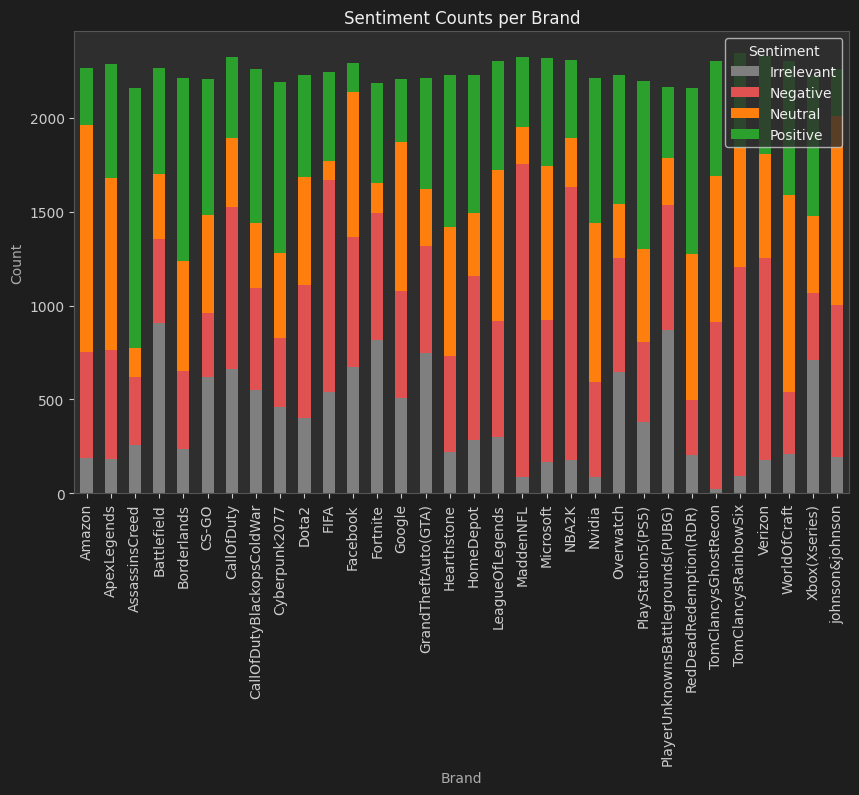

In [117]:
"""
BAR CHART
"""

sentiment_counts = df.groupby("Brand")["Sentiment"].value_counts().unstack(fill_value=0)

colors = {
    "Positive":'#2ca02c',
    "Negative":"#e05151",
    "Neutral":'#ff7f0e',
    "Irrelevant":'#7f7f7f'
}

sentiment_counts.plot(kind="bar", stacked=True, figsize=(10,6), color=[colors[col] for col in sentiment_counts.columns])

plt.title("Sentiment Counts per Brand")
plt.ylabel("Count")
plt.xlabel("Brand")
plt.xticks(rotation=90)
plt.show()

In [118]:
df["Brand"].unique()

array(['Borderlands', 'CallOfDutyBlackopsColdWar', 'Amazon', 'Overwatch',
       'Xbox(Xseries)', 'NBA2K', 'Dota2', 'PlayStation5(PS5)',
       'WorldOfCraft', 'CS-GO', 'Google', 'AssassinsCreed', 'ApexLegends',
       'LeagueOfLegends', 'Fortnite', 'Microsoft', 'Hearthstone',
       'Battlefield', 'PlayerUnknownsBattlegrounds(PUBG)', 'Verizon',
       'HomeDepot', 'FIFA', 'RedDeadRedemption(RDR)', 'CallOfDuty',
       'TomClancysRainbowSix', 'Facebook', 'GrandTheftAuto(GTA)',
       'MaddenNFL', 'johnson&johnson', 'Cyberpunk2077',
       'TomClancysGhostRecon', 'Nvidia'], dtype=object)

In [119]:
"""
CATEGORIZE
"""

games = [
    'Borderlands', 'CallOfDutyBlackopsColdWar', 'Overwatch', 'NBA2K', 'Dota2',
    'WorldOfCraft', 'CS-GO', 'AssassinsCreed', 'ApexLegends', 'LeagueOfLegends',
    'Fortnite', 'Hearthstone', 'Battlefield', 'PlayerUnknownsBattlegrounds(PUBG)',
    'FIFA', 'RedDeadRedemption(RDR)', 'CallOfDuty', 'TomClancysRainbowSix',
    'GrandTheftAuto(GTA)', 'MaddenNFL', 'Cyberpunk2077', 'TomClancysGhostRecon'
]
tech = ['Facebook', 'Google', 'Microsoft', 'Nvidia', 'Amazon', 'Verizon']
consoles = ['PlayStation5(PS5)', 'Xbox(Xseries)']
retail = ['HomeDepot', 'johnson&johnson']

def categorize(name):
    if name in games:
        return "Games"
    elif name in tech:
        return "Tech"
    elif name in consoles:
        return "Consoles"
    elif name in retail:
        return "Retail"
    else:
        return "Other"

df['Category'] = df['Brand'].map(categorize)


In [120]:
"""
GAMES SENTIMENT ANALYSIS
"""
games_df = df[df["Category"]=="Games"]

sentiment_counts = games_df.groupby("Brand")["Sentiment"].value_counts().unstack(fill_value=0)
print(sentiment_counts)

Sentiment                          Irrelevant  Negative  Neutral  Positive
Brand                                                                     
ApexLegends                               185       579      915       610
AssassinsCreed                            256       366      153      1385
Battlefield                               908       449      345       565
Borderlands                               238       415      584       974
CS-GO                                     622       337      525       723
CallOfDuty                                660       866      368       428
CallOfDutyBlackopsColdWar                 549       546      344       822
Cyberpunk2077                             462       363      458       910
Dota2                                     402       706      579       542
FIFA                                      538      1130      100       477
Fortnite                                  818       676      161       532
GrandTheftAuto(GTA)      

In [121]:
sentiment_counts["PositivePct"] = (sentiment_counts["Positive"]/sentiment_counts.sum(axis=1) * 100).round(2)
sentiment_counts["NegativePct"] = (sentiment_counts["Negative"]/sentiment_counts.sum(axis=1) * 100).round(2)
sentiment_counts["NeutralPct"] = (sentiment_counts["Neutral"]/sentiment_counts.sum(axis=1) * 100).round(2)

best5 = sentiment_counts.sort_values("PositivePct", ascending=False).head(5)
worst5 = sentiment_counts.sort_values("NegativePct", ascending=False).head(5)


In [122]:

best5[["PositivePct"]]

Sentiment,PositivePct
Brand,
AssassinsCreed,64.12
Borderlands,44.05
Cyberpunk2077,41.50
RedDeadRedemption(RDR),41.07
CallOfDutyBlackopsColdWar,36.36


In [123]:

worst5[["NegativePct"]]

Sentiment,NegativePct
Brand,
MaddenNFL,71.41
NBA2K,62.61
FIFA,49.86
TomClancysRainbowSix,47.05
TomClancysGhostRecon,38.20


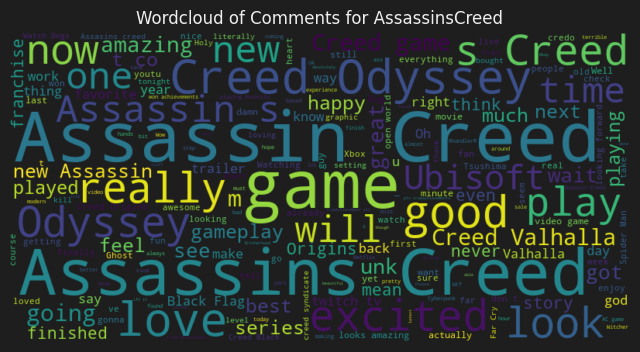

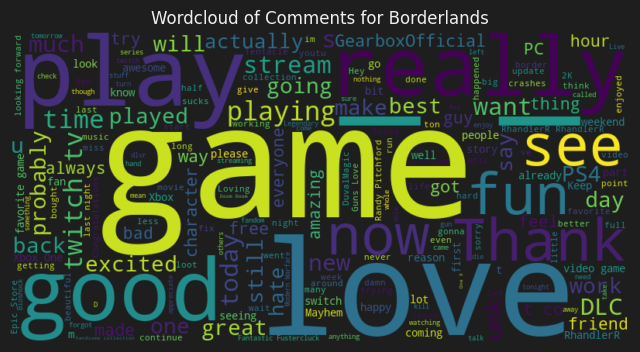

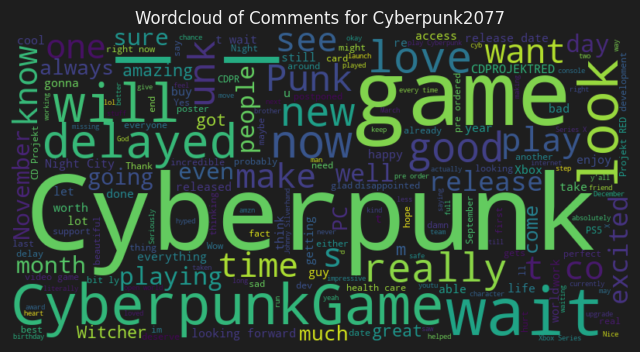

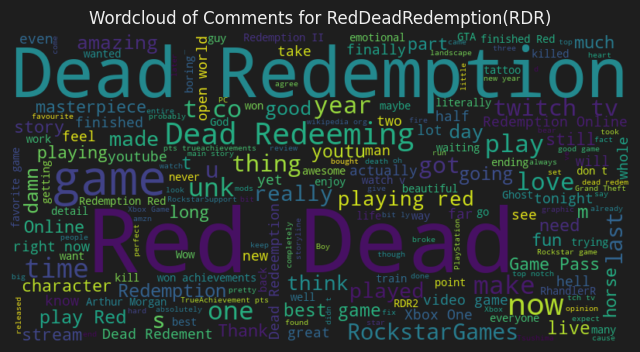

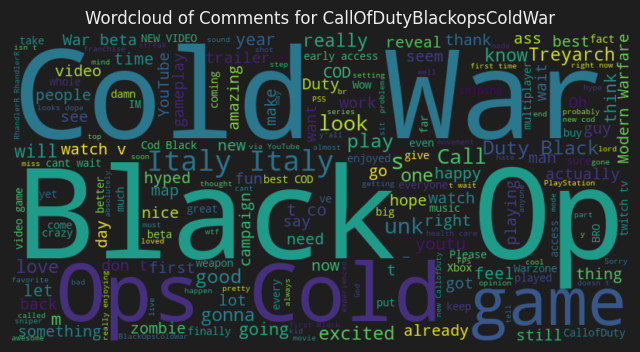

In [124]:
"""
WHAT IS SO LIKED ABOUT TOP 5?
"""

from wordcloud import WordCloud, STOPWORDS

best5games = best5.index.tolist()

for game in best5games:
    comments_text = " ".join(games_df[games_df["Brand"]==game]["Comment"].dropna().astype(str))
    stopwords = set(STOPWORDS)
    stopwords.update([game.lower(), "http", "https", "pic", "twitter","fucking","shit","fuck"])
    wordcloud=WordCloud(width=800, height=400, background_color='#1E1E1E', stopwords=stopwords).generate(comments_text)

    plt.figure(figsize=(8,8))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Wordcloud of Comments for {game}")
    plt.show()

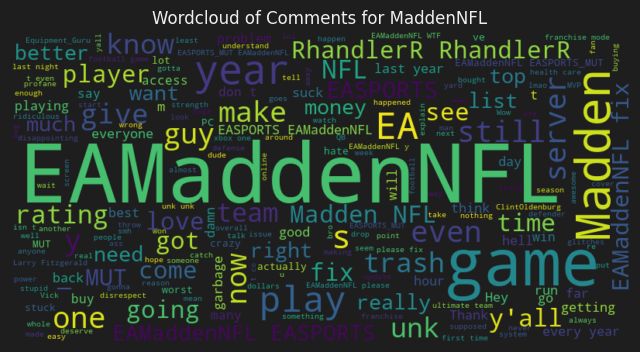

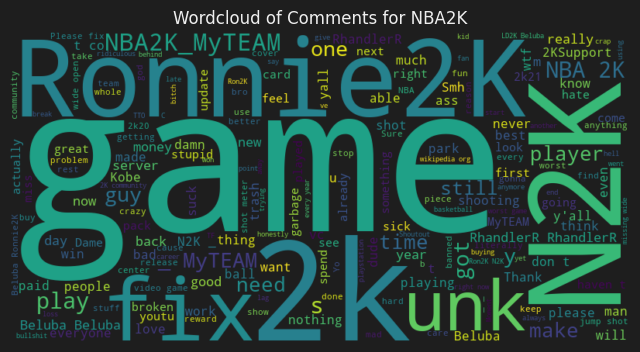

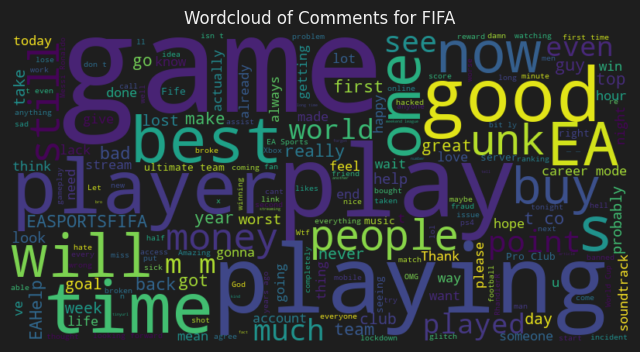

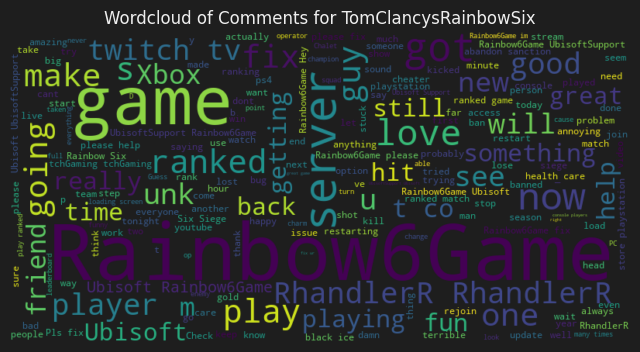

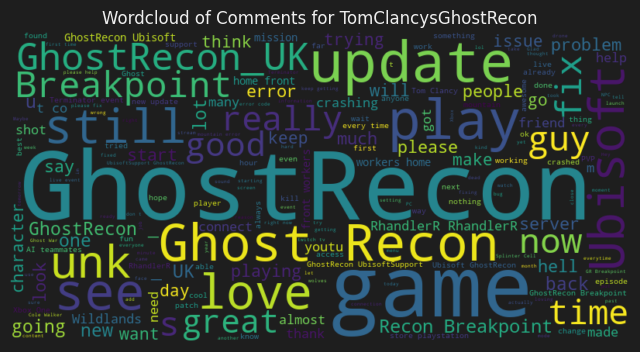

In [125]:
"""
WHAT IS SO DISLIKED ABOUT WORST 5?
"""

worst5games = worst5.index.tolist()

for game in worst5games:
    comments_text = " ".join(games_df[games_df["Brand"]==game]["Comment"].dropna().astype(str))
    stopwords = set(STOPWORDS)
    stopwords.update([game.lower(), "http", "https", "pic", "twitter", "fucking","shit","fuck"])
    wordcloud=WordCloud(width=800, height=400, background_color='#1E1E1E', stopwords=stopwords).generate(comments_text)

    plt.figure(figsize=(8,8))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Wordcloud of Comments for {game}")
    plt.show()

In [126]:
"""
TECH COMPANIES ANALYSIS
"""

tech_df = df[df["Category"]=="Tech"]

sentiment_counts = tech_df.groupby("Brand")["Sentiment"].value_counts().unstack(fill_value=0)

sentiment_counts["PositivePct"] = (sentiment_counts["Positive"]/(sentiment_counts["Positive"] + sentiment_counts["Negative"]) * 100).round(2)
sentiment_counts["NegativePct"] = (sentiment_counts["Negative"]/(sentiment_counts["Positive"] + sentiment_counts["Negative"]) * 100).round(2)

sentiment_counts_pos = sentiment_counts.sort_values("PositivePct", ascending=False)
sentiment_counts_pos

Sentiment,Irrelevant,Negative,Neutral,Positive,PositivePct,NegativePct
Brand,,,,,,
Nvidia,86,505,851,769,60.36,39.64
Microsoft,169,752,823,575,43.33,56.67
Google,508,571,792,339,37.25,62.75
Amazon,187,566,1207,304,34.94,65.06
Verizon,179,1074,555,520,32.62,67.38
Facebook,674,692,773,154,18.20,81.80


In [127]:

sentiment_counts_neg = sentiment_counts.sort_values("NegativePct", ascending=False)
sentiment_counts_neg

Sentiment,Irrelevant,Negative,Neutral,Positive,PositivePct,NegativePct
Brand,,,,,,
Facebook,674,692,773,154,18.20,81.80
Verizon,179,1074,555,520,32.62,67.38
Amazon,187,566,1207,304,34.94,65.06
Google,508,571,792,339,37.25,62.75
Microsoft,169,752,823,575,43.33,56.67
Nvidia,86,505,851,769,60.36,39.64


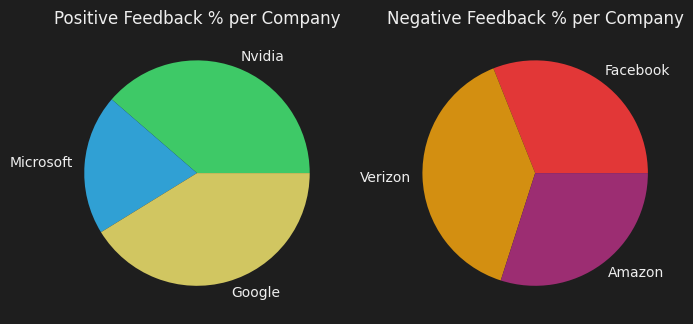

In [128]:
"""
PIE CHART
"""

plt.figure(figsize=(8,8))

plt.subplot(1,2,1)
colors_pos = ["#3EC967","#30A0D4","#D1C661"]
plt.pie(sentiment_counts["PositivePct"].head(3), labels=sentiment_counts_pos.head(3).index, colors=colors_pos)
plt.title("Positive Feedback % per Company")

plt.subplot(1,2,2)
colors_neg = ["#E23737","#D38F11","#9C2D72"]
plt.pie(sentiment_counts["NegativePct"].head(3), labels=sentiment_counts_neg.head(3).index, colors=colors_neg)
plt.title("Negative Feedback % per Company")

plt.show()

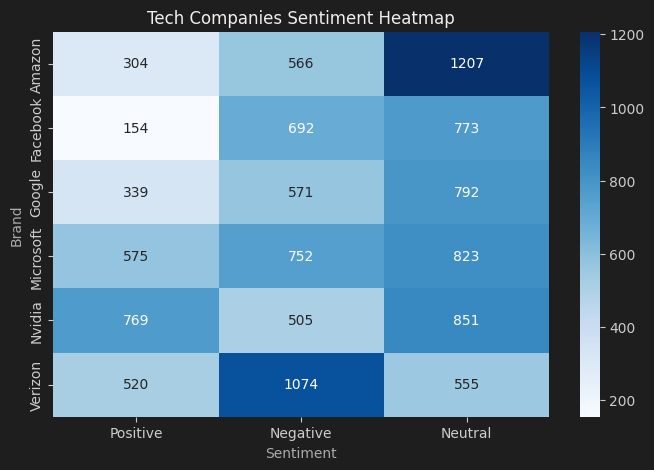

In [129]:
"""
HEAT MAP
"""
import seaborn as sns

plt.figure(figsize=(8,5))
sns.heatmap(sentiment_counts[["Positive", "Negative", "Neutral"]], annot=True, fmt="d", cmap="Blues")
plt.title("Tech Companies Sentiment Heatmap")
plt.show()

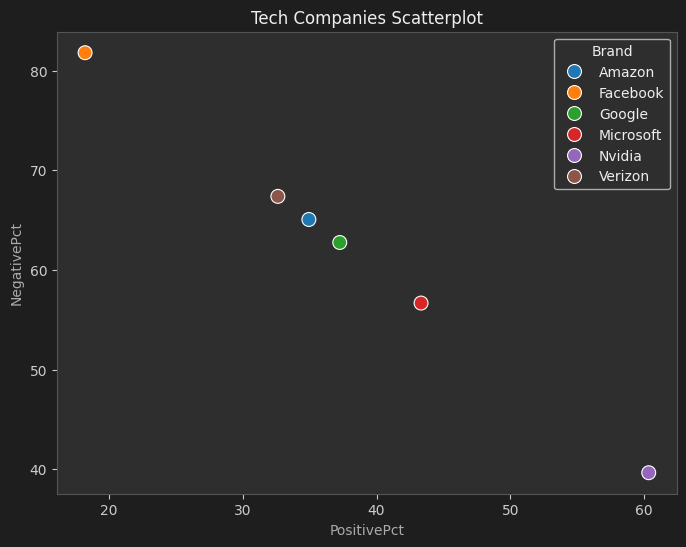

In [160]:
"""
SCATTERPLOT
"""

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=sentiment_counts,
    x="PositivePct",
    y="NegativePct",
    hue="Brand",
    palette="tab10",
    s=100
)
plt.title("Tech Companies Scatterplot")
plt.show()

In [161]:
"""
CONSOLES
"""
consoles_df = df[df["Category"]=="Consoles"]

consoles_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4418 entries, 9312 to 18671
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   ID         4418 non-null   int64 
 1   Brand      4418 non-null   object
 2   Sentiment  4418 non-null   object
 3   Comment    4384 non-null   object
 4   Category   4418 non-null   object
dtypes: int64(1), object(4)
memory usage: 207.1+ KB


In [162]:
console_sent = consoles_df.groupby("Brand")["Sentiment"].value_counts().unstack(fill_value=0)

console_sent["PosPerc"] = (console_sent["Positive"] / (console_sent["Positive"]+console_sent["Negative"]) * 100).round(2)
console_sent["NegPerc"] = (console_sent["Negative"] / (console_sent["Positive"]+console_sent["Negative"]) * 100).round(2)
console_sent["All"] = console_sent["Negative"] + console_sent["Positive"] + console_sent["Neutral"] + console_sent["Irrelevant"]
console_sent["PosNegNeut"] = console_sent["Negative"] + console_sent["Positive"] + console_sent["Neutral"]

console_sent

Sentiment,Irrelevant,Negative,Neutral,Positive,PosPerc,NegPerc,All,PosNegNeut
Brand,,,,,,,,
PlayStation5(PS5),382,425,495,894,67.78,32.22,2196,1814
Xbox(Xseries),712,357,406,747,67.66,32.34,2222,1510


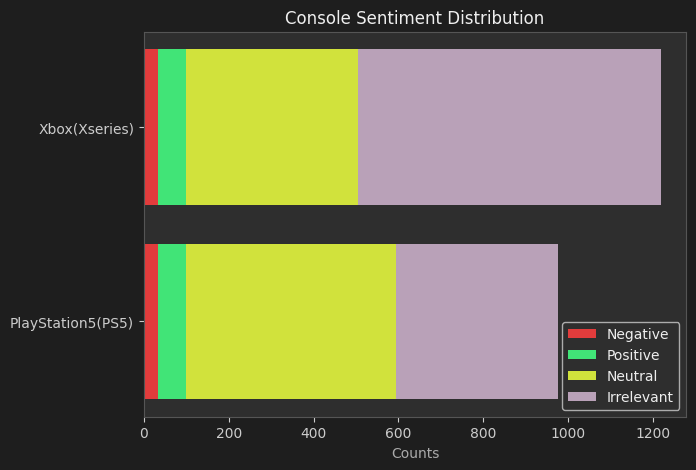

In [175]:
"""
BAR STACKED HORIZONTAL FOR CONSOLES
"""

plt.figure(figsize=(7,5))

plt.barh(console_sent.index, console_sent["NegPerc"], color="#e23c3c", label="Negative")
plt.barh(console_sent.index, console_sent["PosPerc"], left=console_sent["NegPerc"], color="#41e477", label="Positive")
plt.barh(console_sent.index, console_sent["Neutral"], left=console_sent["NegPerc"]+console_sent["PosPerc"], color="#d1e23c", label="Neutral")
plt.barh(console_sent.index, console_sent["Irrelevant"], left=console_sent["NegPerc"]+console_sent["PosPerc"]+console_sent["Neutral"], color="#B9A1B8", label="Irrelevant")

plt.legend()
plt.xlabel("Counts")
plt.title("Console Sentiment Distribution")
plt.legend()
plt.show()


In [181]:
"""
RETAIL
"""

retail_df = df[df["Category"] =="Retail"]

retail_sent = retail_df.groupby("Brand")["Sentiment"].value_counts().unstack(fill_value=0)

retail_sent["PosPerc"] = (retail_sent["Positive"] / (retail_sent["Positive"]+retail_sent["Negative"]) * 100).round(2)
retail_sent["NegPerc"] = (retail_sent["Negative"] / (retail_sent["Positive"]+retail_sent["Negative"]) * 100).round(2)
retail_sent["All"] = retail_sent["Negative"] + retail_sent["Positive"] + retail_sent["Neutral"] + retail_sent["Irrelevant"]
retail_sent["PosNegNeut"] = retail_sent["Negative"] + retail_sent["Positive"] + retail_sent["Neutral"]

retail_sent

Sentiment,Irrelevant,Negative,Neutral,Positive,PosPerc,NegPerc,All,PosNegNeut
Brand,,,,,,,,
HomeDepot,285,875,331,735,45.65,54.35,2226,1941
johnson&johnson,193,810,1005,253,23.80,76.20,2261,2068


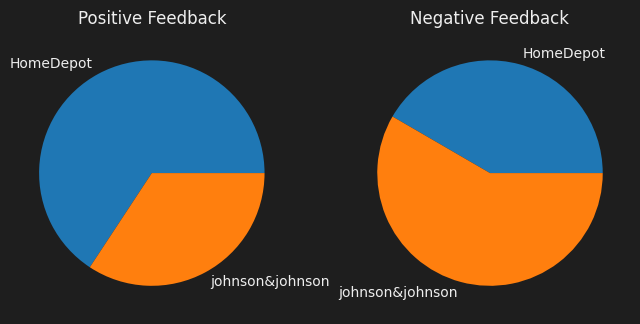

In [184]:
"""
PIE CHART
"""

plt.figure(figsize=(8,8))

plt.subplot(1,2,1)
plt.pie(retail_sent["PosPerc"], labels=retail_sent.index)
plt.title("Positive Feedback")

plt.subplot(1,2,2)
plt.pie(retail_sent["NegPerc"], labels=retail_sent.index)
plt.title("Negative Feedback")

plt.show()